## 📘 PART 1 — Import Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

## 📘 PART 2 — Load Dataset

In [2]:
df = pd.read_csv("cancer_detection.csv")  # Change name if needed
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 📘 PART 3 — Data Info and Cleaning

In [3]:
df.info()
df.describe()
df.isnull().sum()
print("Shape:", df.shape)
print("Columns:", df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 📘 PART 4 — Data Visualization (Histograms, Countplot)

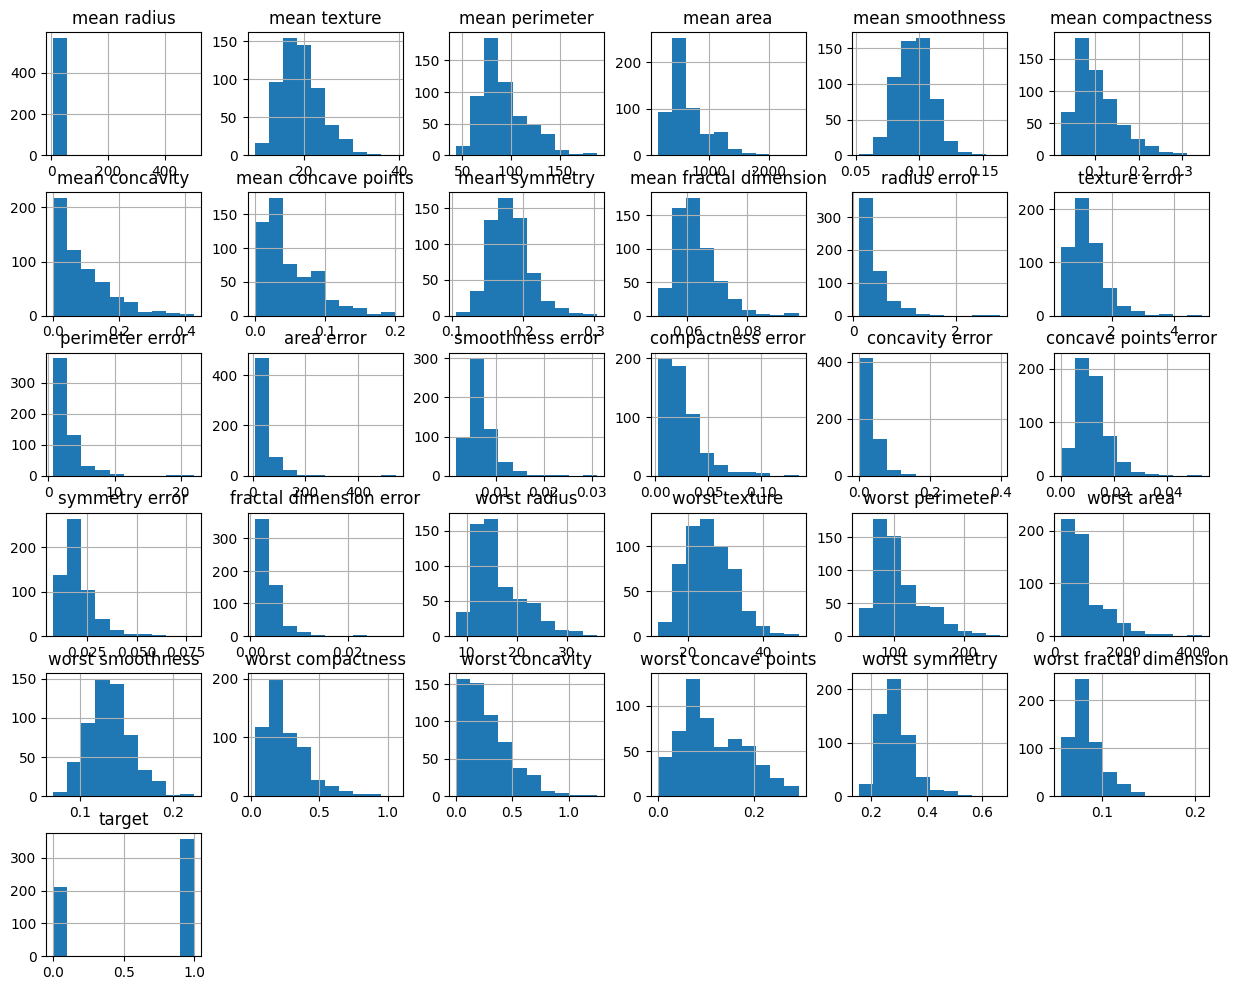

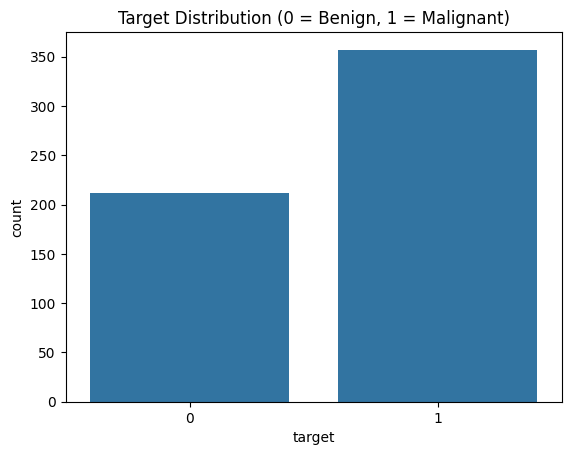

In [4]:
df.hist(figsize=(15, 12))
plt.show()

sns.countplot(x=df["target"])
plt.title("Target Distribution (0 = Benign, 1 = Malignant)")
plt.show()

## 📘 PART 5 — Correlation Heatmap

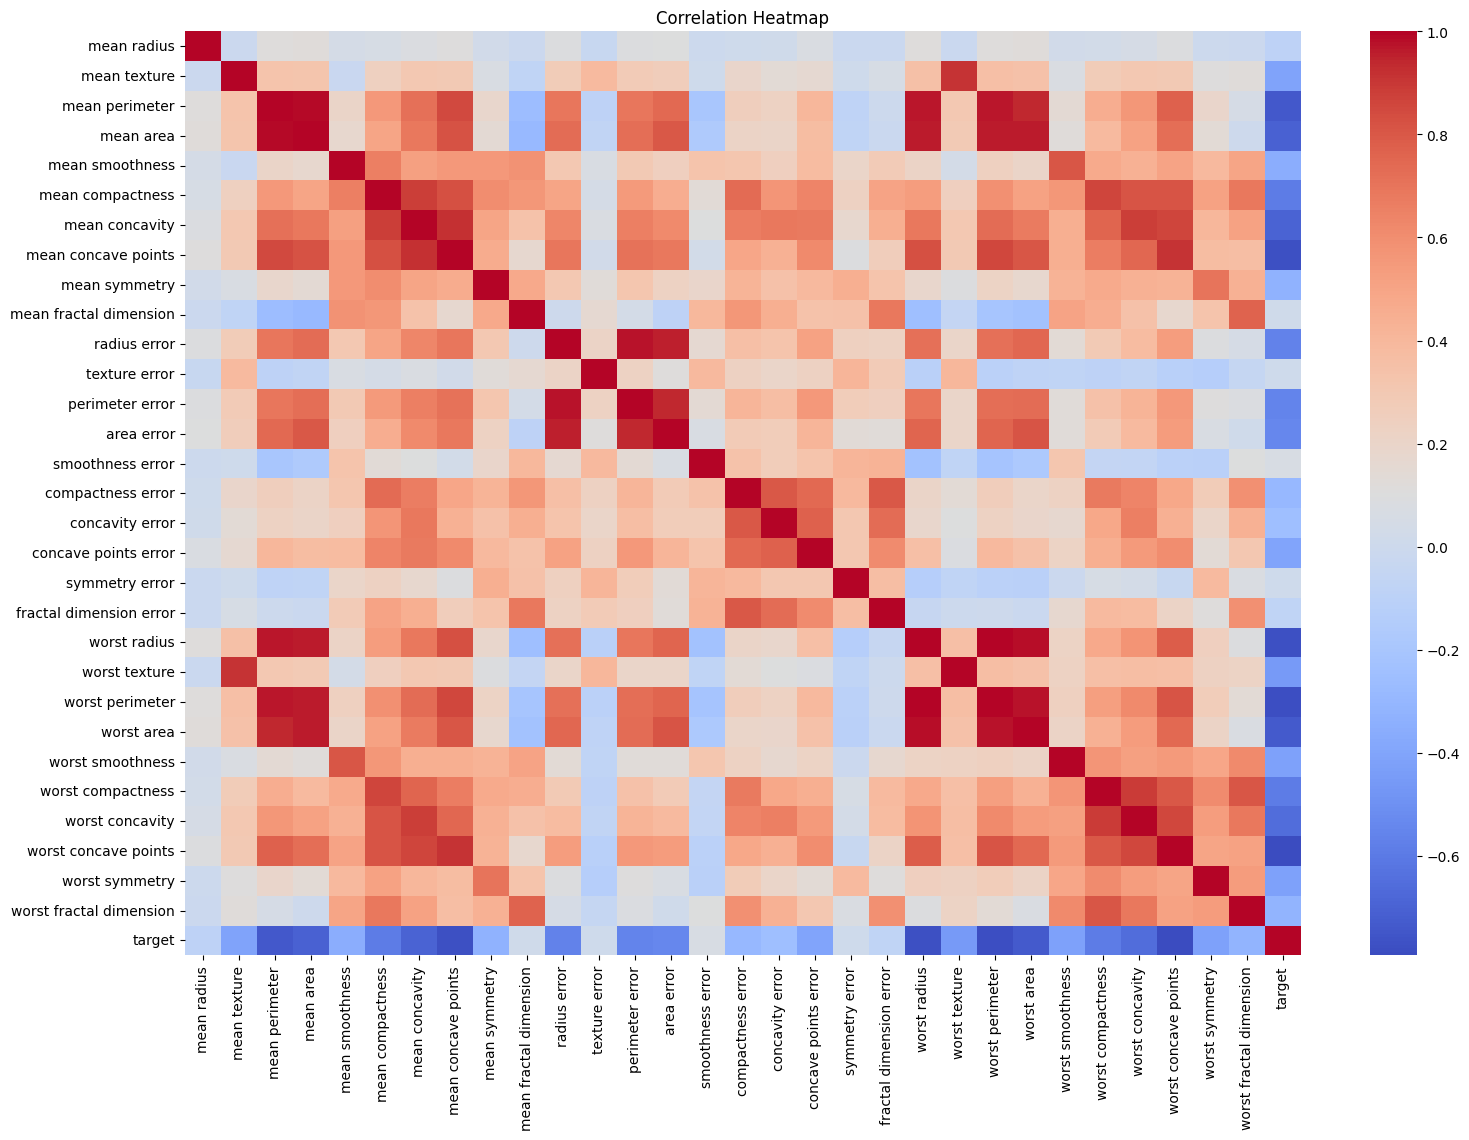

In [5]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 📘 PART 6 — Correlation Bar Plot

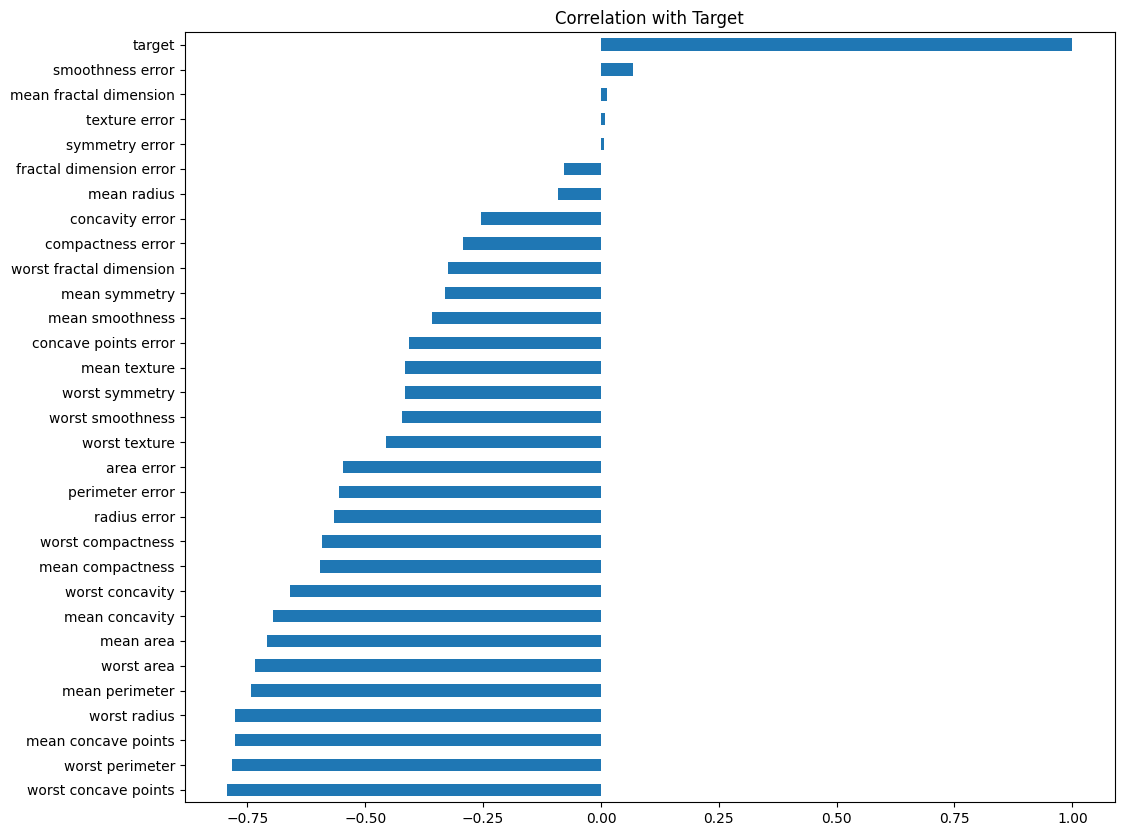

In [6]:
df.corr()["target"].sort_values().plot(kind="barh", figsize=(12, 10))
plt.title("Correlation with Target")
plt.show()

## 📘 PART 7 — Train/Test Split + Scaling

In [7]:
X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 📘 PART 8 — Feature Selection (SelectKBest)

In [8]:
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_scaled, y)

selected_features = selector.get_support(indices=True)
print("Top 10 Selected Feature Indexes:", selected_features)

Top 10 Selected Feature Indexes: [ 2  3  5  6  7 20 22 23 26 27]


## 📘 PART 9 — SVC Model

In [10]:
svc = SVC()
svc.fit(X_train, y_train)
pred_svc = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, pred_svc))
print(classification_report(y_test, pred_svc))

SVC Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 📘 PART 9B — Logistic Regression

In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 📘 PART 9C — KNN Classifier

In [10]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

KNN Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 📘 PART 9D — Naive Bayes Classifier

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Naive Bayes Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 📘 PART 9E — Decision Tree Classifier

In [12]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        43
           1       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



## 📘 PART 9F — Random Forest Classifier (BEST MODEL)

In [13]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 📘 PART 10 — Grid Search CV for Random Forest

In [14]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Grid Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 300}
Best Grid Score: 0.9648351648351647


## 📘 PART 11 — Confusion Matrix

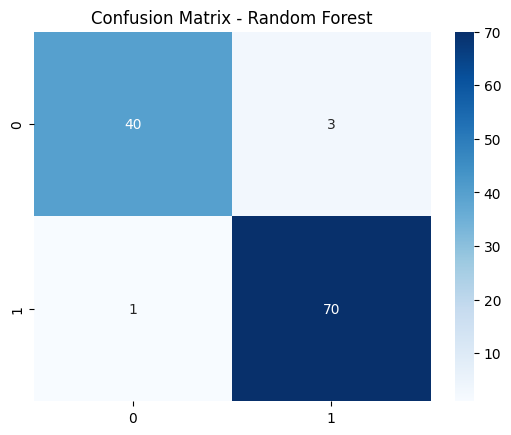

In [15]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 📘 PART 12 — Cross Validation

In [16]:
cv = cross_val_score(rf, X_scaled, y, cv=10)
print("Cross Validation Scores:", cv)
print("Mean CV Score:", cv.mean())

Cross Validation Scores: [0.98245614 0.89473684 0.94736842 0.96491228 0.98245614 0.98245614
 0.94736842 0.98245614 0.94736842 1.        ]
Mean CV Score: 0.9631578947368421


## 📘 PART 13 — Save Random Forest Model

In [17]:
joblib.dump(rf, "cancer_random_forest.pkl")
print("Model Saved Successfully: cancer_random_forest.pkl")

Model Saved Successfully: cancer_random_forest.pkl
